## Fingerprint Enhancement & Minutiae Detection Using Gabor Filtering

This project explores a computer vision pipeline for enhancing latent fingerprint images and detecting candidate fingerprint features. It combines contrast enhancement, custom strided filtering, gradient analysis and Gabor filtering to improve ridge visibility before feature detection.

The input images contain fingerprints captured from glass and a kettle surface. These uncontrolled conditions introduce challenges such as low contrast, uneven lighting, background noise and fragmented ridge patterns.

The enhancement approach is informed by:

> Hong, L., Wan, Y., and Jain, A. K. (1998). Fingerprint image enhancement: Algorithm and performance evaluation. IEEE Transactions on Pattern Analysis and Machine Intelligence, 20(8), 777–789.

## Objectives

- Improve fingerprint ridge visibility in challenging images.
- Implement custom strided filtering and examine image gradients.
- Explore how Gabor filtering affects fingerprint enhancement.
- Detect candidate features and compare results before and after enhancement.
- Investigate parameter sensitivity across different input images.

## Methodology

### 1. Image Preparation

Load the input images using OpenCV, convert them to grayscale and crop the regions containing the fingerprints.

### 2. Contrast Enhancement

Apply histogram equalisation using `cv2.equalizeHist` to improve contrast in the cropped images.

### 3. Custom Strided Filtering

Implement `my_conv`, a custom two-dimensional cross-correlation function supporting configurable strides without padding or kernel flipping.

### 4. Gradient Analysis

Apply Gaussian smoothing to reduce noise, then compute horizontal and vertical gradients using Sobel filters. Calculate per-pixel gradient orientation using `atan2(Gy, Gx)`.

Compare different Gaussian kernel sizes and standard deviations to examine the balance between noise reduction and ridge-detail preservation.

### 5. Block-Level Orientation Analysis

Compute average gradient orientations within image blocks using an averaging kernel and strided filtering. Visualise the orientation distribution with a histogram and explore different block sizes and orientation-bin counts.

### 6. Gabor Filtering

Generate a bank of Gabor filters at the orientation-bin centres and apply each filter to the contrast-enhanced image. Visualise the kernels and their responses to inspect how different orientations emphasise ridge patterns.

### 7. Response Aggregation and Binarisation

Combine the filtered images by taking the maximum response at each pixel. Apply a relative threshold to produce a binary enhanced image, then compare it with an Otsu-thresholded baseline.

### 8. Candidate Feature Detection

Use OpenCV's Shi–Tomasi corner detector to identify candidate fingerprint features. Overlay the detected points and compare detections on the enhanced binary image with those on the equalised image.

These points are candidate features rather than verified ridge endings or bifurcations.

### 9. Parameter Exploration and Result Export

Compare enhancement and detection settings across both input images. Explore smoothing, Gabor filter parameters, threshold ratios and corner-detector settings.

Save annotated outputs using `cv2.imwrite` and display them for visual comparison.

### 10. Results and Limitations

Discuss the contribution of each processing stage, the effect of parameter choices and the differences between the two input images.

Consider limitations including manual tuning, background noise, fixed ridge wavelength and the use of corner detection as a proxy for candidate minutiae. Visual comparisons support qualitative assessment; detection accuracy requires ground-truth annotations.

## Implementation Notes

The project uses Python, NumPy, OpenCV and Matplotlib. The initial Gabor helper was supplied with the source materials; the surrounding implementation includes preprocessing, custom strided filtering, gradient analysis, response aggregation, parameter exploration and feature visualisation.

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

### Step 1: Image Loading and Region Selection

In [2]:
# Load the first image [glass.png] using OpenCV 
glass_img = cv2.imread('glass.png')
# Load the second image [reddit.jpeg] using OpenCV
reddit_img = cv2.imread('reddit.jpeg')

# Convert both imagesto grayscale 
gray_glass_img = cv2.cvtColor(glass_img, cv2.COLOR_BGR2GRAY)
gray_reddit_img = cv2.cvtColor(reddit_img, cv2.COLOR_BGR2GRAY)

# Create a single figure for all 4 plots
plt.figure(figsize=(12, 10))

# [glass.png]
# Display the original grayscale (to find crop coordinates)
plt.subplot(2, 2, 1)
plt.imshow(gray_glass_img, cmap='gray')
plt.title("Original Grayscale [glass.png]")

# Crop to the fingerprint region
cropped_glass_img = gray_glass_img[70:750, 550:1080]

# Display the cropped Fingerprint
plt.subplot(2, 2, 3) 
plt.imshow(cropped_glass_img, cmap='gray')
plt.title("Cropped Fingerprint [glass.png]")

# [reddit.jpeg]
# Display the original grayscale (to find crop coordinates)
plt.subplot(2, 2, 2)
plt.imshow(gray_reddit_img, cmap='gray')
plt.title("Original Grayscale [reddit.jpeg]")

# Crop to the fingerprint region
cropped_reddit_img = gray_reddit_img[1560:2350, 1220:1700]

# Display the cropped Fingerprint
plt.subplot(2, 2, 4) 
plt.imshow(cropped_reddit_img, cmap='gray')
plt.title("Cropped Fingerprint [reddit.jpeg]")

plt.tight_layout() 
plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


### Step 2: Contrast Enhancement

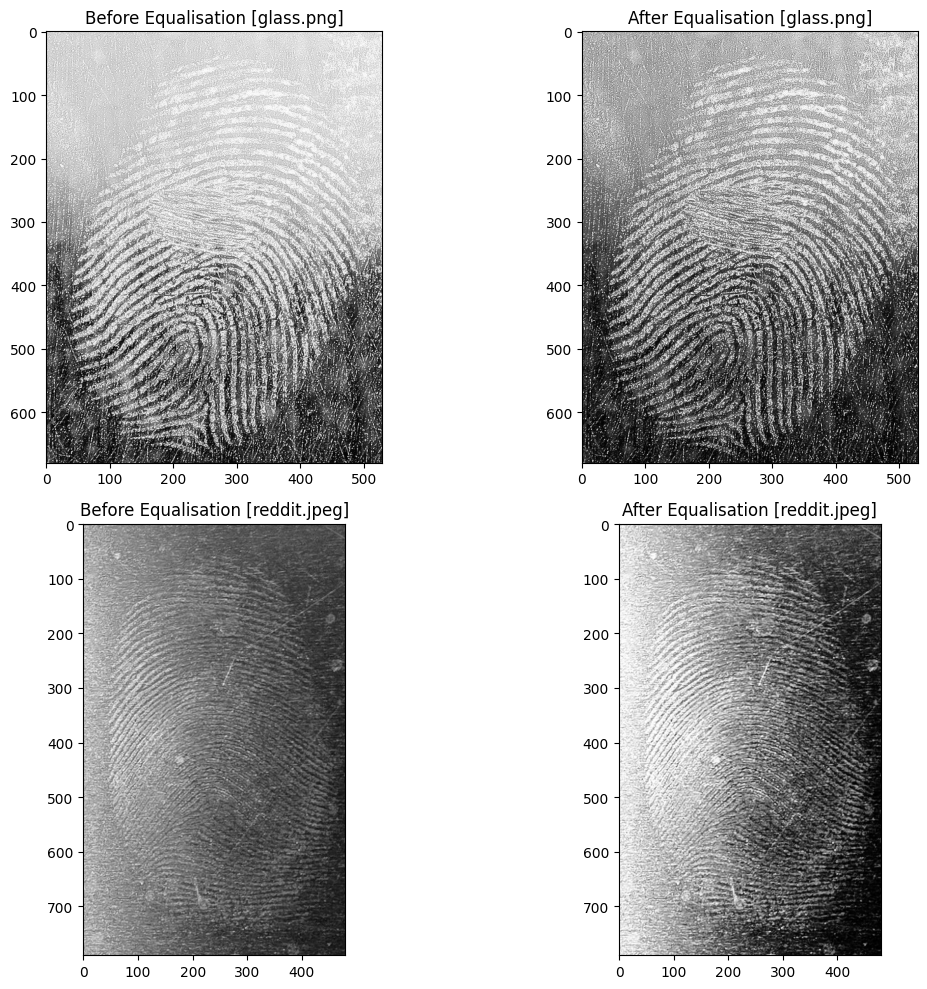

In [ ]:
# Apply histogram equalisation to both cropped greyscale images
eq_glass_img = cv2.equalizeHist(cropped_glass_img)
eq_reddit_img = cv2.equalizeHist(cropped_reddit_img)

# Display before and after for both images
plt.figure(figsize=(12, 10))

# glass.png - before
plt.subplot(2, 2, 1)
plt.imshow(cropped_glass_img, cmap='gray')
plt.title("Before Equalisation [glass.png]")

# glass.png - after
plt.subplot(2, 2, 2)
plt.imshow(eq_glass_img, cmap='gray')
plt.title("After Equalisation [glass.png]")

# reddit.jpeg - before
plt.subplot(2, 2, 3)
plt.imshow(cropped_reddit_img, cmap='gray')
plt.title("Before Equalisation [reddit.jpeg]")

# reddit.jpeg - after
plt.subplot(2, 2, 4)
plt.imshow(eq_reddit_img, cmap='gray')
plt.title("After Equalisation [reddit.jpeg]")

plt.tight_layout()
plt.show()

### Step 3: Custom Strided Cross-Correlation

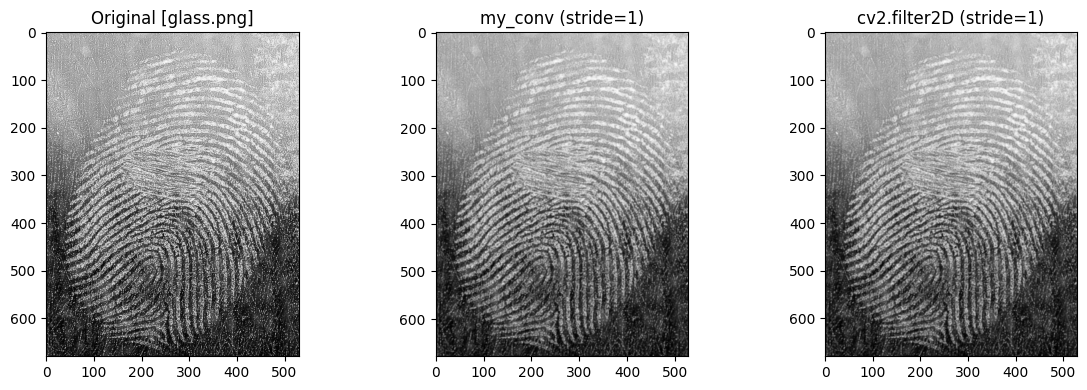

my_conv output shape    : (678, 528)
cv2.filter2D output shape: (680, 530)
Max difference between outputs: 0.444458


In [ ]:
def my_conv(image, kernel, stride=1):
    """
    Performs a 2D convolution (cross-correlation) on a grayscale image.
    No padding, no kernel flipping.
    
    Args:
        image  : 2D numpy array (grayscale image)
        kernel : 2D numpy array (filter/kernel)
        stride : int, step size for sliding the kernel (default=1)
    
    Returns:
        output : 2D numpy array of the filtered image response
    """
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # Calculate output dimensions based on stride
    out_h = (img_h - ker_h) // stride + 1
    out_w = (img_w - ker_w) // stride + 1

    # Initialise output array
    output = np.zeros((out_h, out_w), dtype=np.float32)

    # Slide the kernel across the image with the given stride
    for i in range(out_h):
        for j in range(out_w):
            # Extract the image patch at current position
            row = i * stride
            col = j * stride
            patch = image[row : row + ker_h, col : col + ker_w]

            # Element-wise multiply patch with kernel and sum
            output[i, j] = np.sum(patch * kernel)

    return output


# Quick check: compare my_conv vs cv2.filter2D (stride=1) 
# Simple 3x3 averaging kernel
test_kernel = np.ones((3, 3), dtype=np.float32) / 9.0

my_result    = my_conv(eq_glass_img.astype(np.float32), test_kernel, stride=1)
cv2_result   = cv2.filter2D(eq_glass_img, -1, test_kernel)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(eq_glass_img, cmap='gray')
plt.title("Original [glass.png]")

plt.subplot(1, 3, 2)
plt.imshow(my_result, cmap='gray')
plt.title("my_conv (stride=1)")

plt.subplot(1, 3, 3)
plt.imshow(cv2_result, cmap='gray')
plt.title("cv2.filter2D (stride=1)")

plt.tight_layout()
plt.show()

print("my_conv output shape    :", my_result.shape)
print("cv2.filter2D output shape:", cv2_result.shape)
print("Max difference between outputs:", np.max(np.abs(my_result - cv2_result[1:-1, 1:-1])))

#### Step 4: Compute the orientation of the gradient at each pixel in the image using Sobel filtering

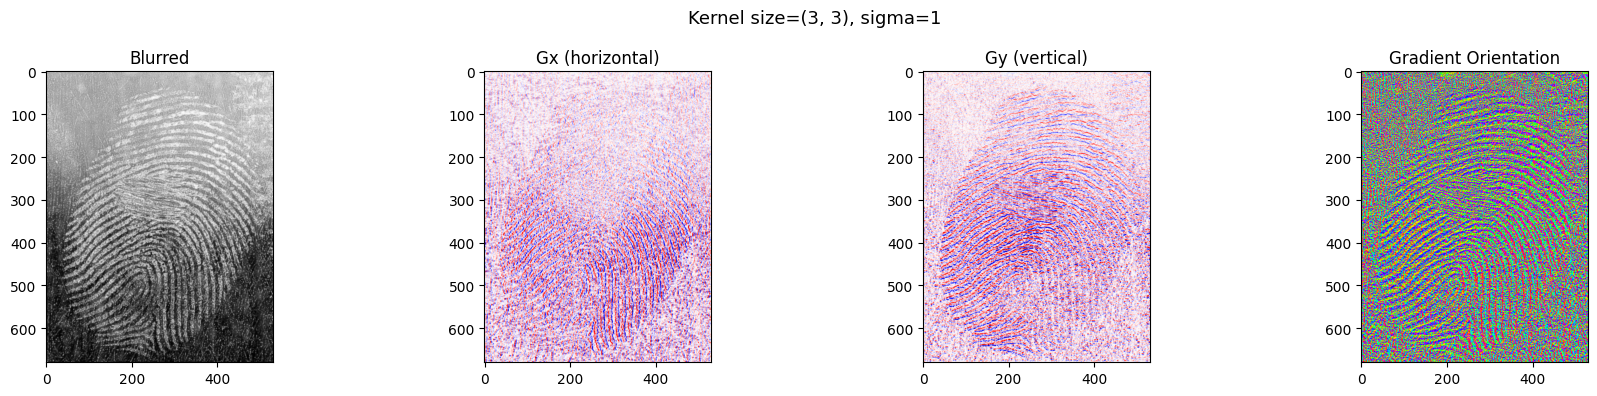

ksize=(3, 3), sigma=1 ; Orientation range: -3.14 to 3.14 rad


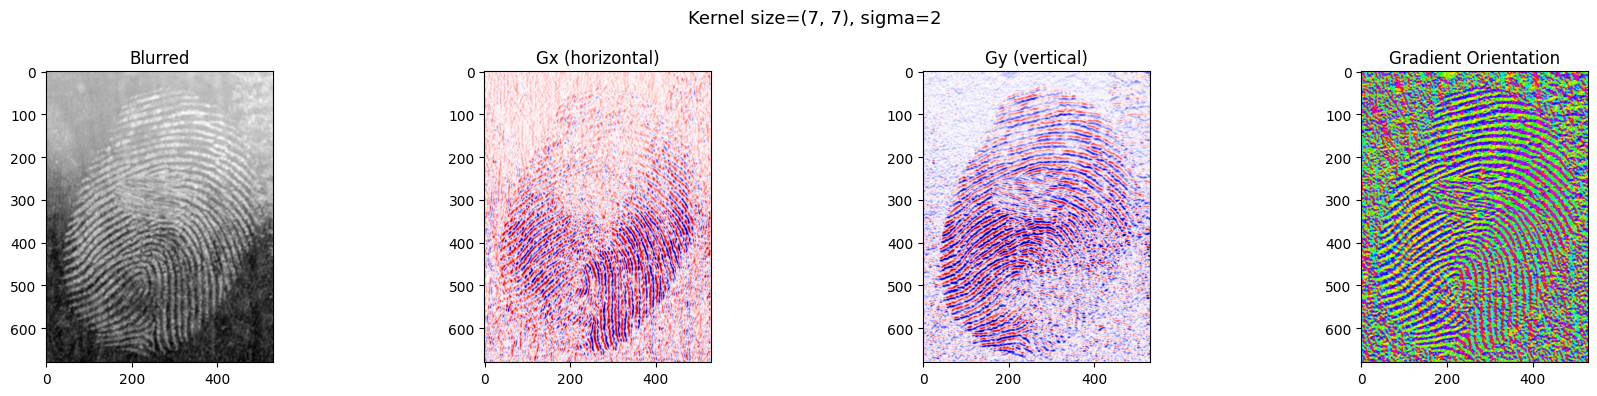

ksize=(7, 7), sigma=2 ; Orientation range: -3.14 to 3.14 rad


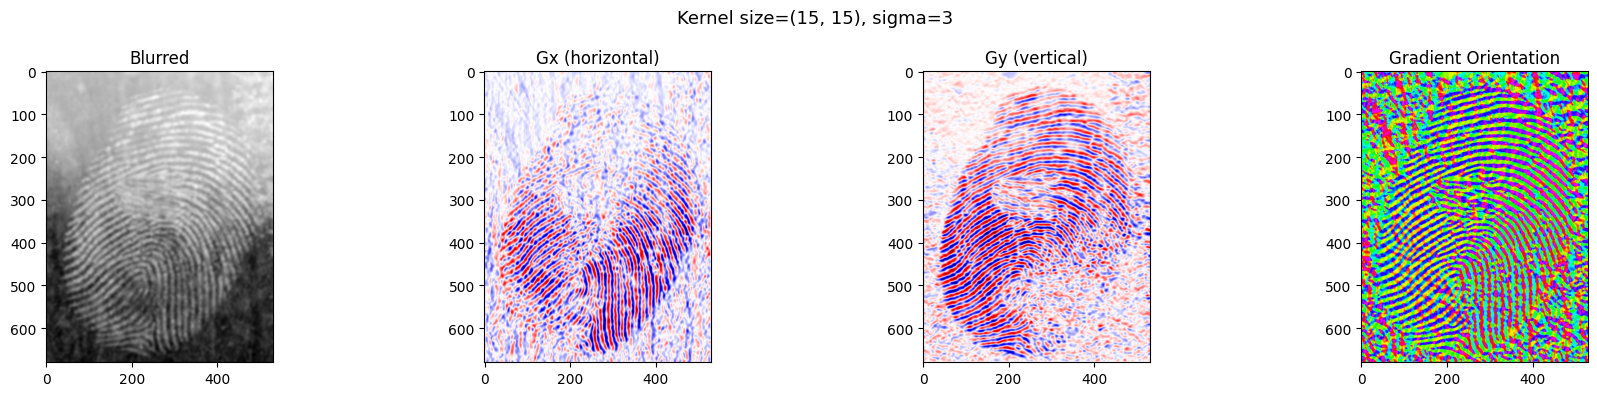

ksize=(15, 15), sigma=3 ; Orientation range: -3.13 to 3.14 rad


In [ ]:
# Create a list of kernel parameters to test (stride is fixed at 1 for this part)
kernel_params = [
    {'ksize': (3, 3),   'sigma': 1},
    {'ksize': (7, 7),   'sigma': 2},
    {'ksize': (15, 15), 'sigma': 3},
]

# Apply Gaussian blur with different kernel sizes and sigmas, then compute Sobel derivatives and gradient orientation
for params in kernel_params:
    ksize = params['ksize']
    sigma = params['sigma']

    # Blur first to reduce noise 
    blurred = cv2.GaussianBlur(eq_glass_img, ksize, sigma)

    # Sobel derivatives 
    Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    # Gradient orientation 
    orientation = np.arctan2(Gy, Gx)

    # Create a figure to display results for this parameter set
    plt.figure(figsize=(18, 4))
    plt.suptitle(f'Kernel size={ksize}, sigma={sigma}', fontsize=13)

    plt.subplot(1, 4, 1)
    plt.imshow(blurred, cmap='gray')
    plt.title('Blurred')

    plt.subplot(1, 4, 2)
    plt.imshow(Gx, cmap='seismic')
    plt.title('Gx (horizontal)')

    plt.subplot(1, 4, 3)
    plt.imshow(Gy, cmap='seismic')
    plt.title('Gy (vertical)')

    plt.subplot(1, 4, 4)
    plt.imshow(orientation, cmap='hsv')
    plt.title('Gradient Orientation')

    plt.tight_layout()
    plt.show()

    print(f"ksize={ksize}, sigma={sigma} ; Orientation range: {orientation.min():.2f} to {orientation.max():.2f} rad")

#### Step 5: Compute the average orientation in image blocks and plot a histogram of the orientations

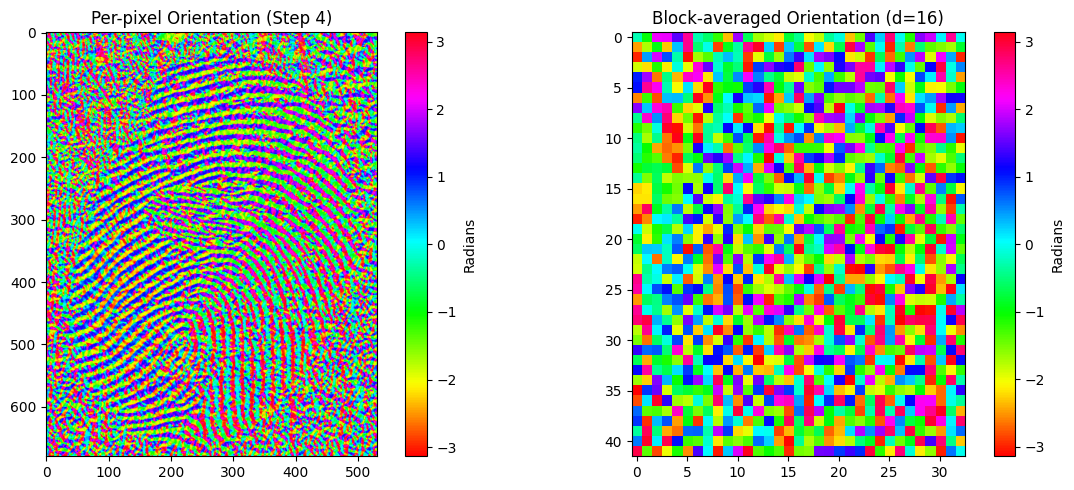

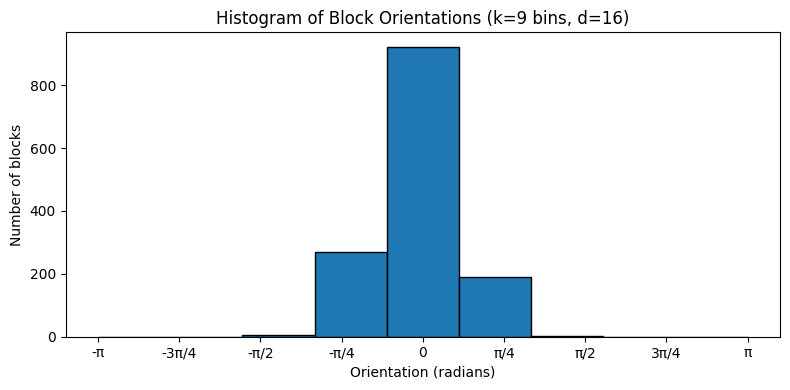

In [ ]:
# Best params chosen from Step 4
KSIZE = (7, 7)
SIGMA = 2

# Recompute blurred, Gx, Gy, and orientation with the chosen parameters
blurred = cv2.GaussianBlur(eq_glass_img, KSIZE, SIGMA)
Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
orientation = np.arctan2(Gy, Gx)

# Display the per-pixel orientation and the block-averaged orientation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(orientation, cmap='hsv')
plt.title('Per-pixel Orientation (Step 4)')
plt.colorbar(label='Radians')

plt.subplot(1, 2, 2)
plt.imshow(avg_orientation, cmap='hsv')
plt.title(f'Block-averaged Orientation (d={d})')
plt.colorbar(label='Radians')

plt.tight_layout()
plt.show()

# Define block size and number of orientation bins
d = 16  # block size
k = 9   # number of orientation bins

# Averaging kernel
avg_kernel = np.ones((d, d), dtype=np.float32) / (d * d)

# Use my_conv with stride=d to get one average orientation per block
avg_orientation = my_conv(orientation.astype(np.float32), avg_kernel, stride=d)

# Compute histogram of block orientations
hist, bin_edges = np.histogram(avg_orientation.ravel(), bins=k, range=(-np.pi, np.pi))
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

# Display the histogram of block orientations
plt.figure(figsize=(8, 4))
plt.bar(bin_centres, hist, width=(2 * np.pi / k), edgecolor='black', align='center')
plt.xlabel('Orientation (radians)')
plt.ylabel('Number of blocks')
plt.title(f'Histogram of Block Orientations (k={k} bins, d={d})')
plt.xticks(np.linspace(-np.pi, np.pi, 9),
           ['-π', '-3π/4', '-π/2', '-π/4', '0', 'π/4', 'π/2', '3π/4', 'π'])
plt.tight_layout()
plt.show()

#### Step 6: Generate gabor filters for each of the orientation bins above, apply these and use matplotlib to visualise both the filters and responses

<Figure size 1500x500 with 0 Axes>

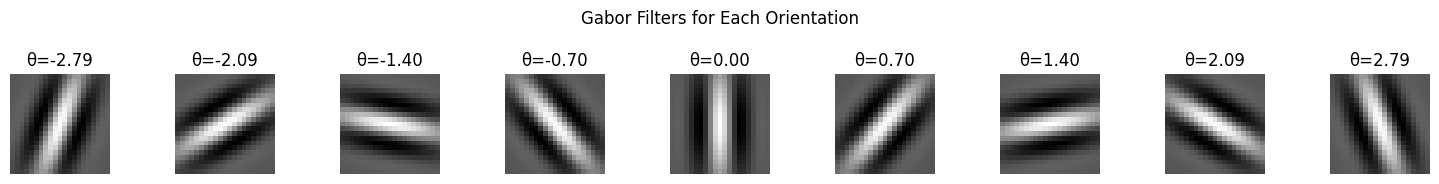

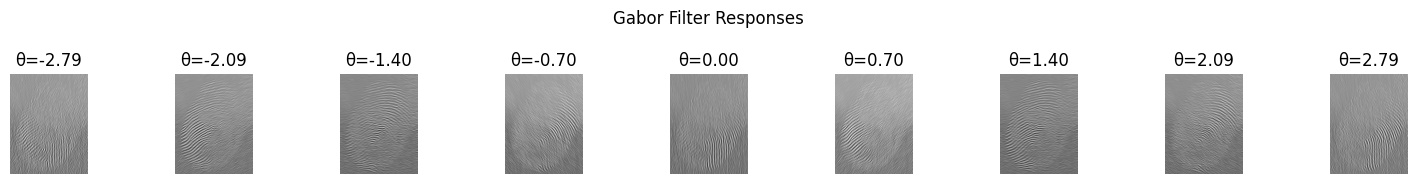

In [ ]:
# Given to students.
def gabor(theta,ksize,sigma,freq):
    
    kern = cv2.getGaborKernel((ksize, ksize), sigma, theta, 10.0, freq, 0, ktype=cv2.CV_64F)
    kern /= 1.0 * kern.sum() 
    
    return kern

# Gabor filter parameters
ksize = 21    # kernel size
sigma = 4     # smoothness
freq  = 0.5   # spatial frequency (tune to match ridge spacing)

# Use the k=12 bin centres as our orientations
gabor_filters    = []
gabor_responses  = []

plt.figure(figsize=(15, 5))
for i, theta in enumerate(bin_centres):
    
    # Generate Gabor filter for this orientation
    kern = gabor(theta, ksize, sigma, freq)
    gabor_filters.append(kern)
    
    # Filter the equalised image with this kernel
    response = cv2.filter2D(eq_glass_img, cv2.CV_64F, kern)
    gabor_responses.append(response)

# Display all filters
plt.figure(figsize=(15, 3))
plt.suptitle('Gabor Filters for Each Orientation', fontsize=12)
for i, kern in enumerate(gabor_filters):
    plt.subplot(2, k, i+1)
    plt.imshow(kern, cmap='gray')
    plt.title(f'θ={bin_centres[i]:.2f}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Display all filter responses
plt.figure(figsize=(15, 3))
plt.suptitle('Gabor Filter Responses', fontsize=12)
for i, response in enumerate(gabor_responses):
    plt.subplot(2, k, i+1)
    plt.imshow(response, cmap='gray')
    plt.title(f'θ={bin_centres[i]:.2f}')
    plt.axis('off')
plt.tight_layout()
plt.show()

#### Step 7: Combine the responses above and show the enhanced image alonside the original one, then threshold the image to retain only fingerprint information

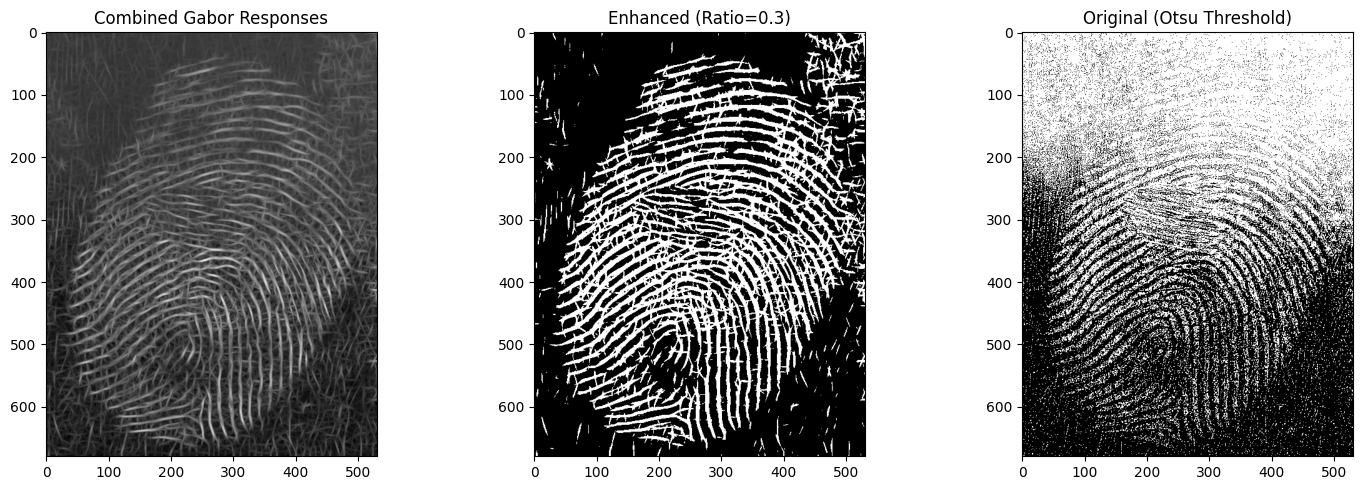

In [ ]:
# Combine all 12 Gabor responses by taking max at each pixel
# Stack list into a 3D array and find max along axis 0
combined_enhanced = np.max(np.array(gabor_responses), axis=0)

# Threshold the enhanced image using best ratio found by try and error (0.3)
thresh_ratio = 0.3  
enhanced_binary = (combined_enhanced > thresh_ratio * combined_enhanced.max()).astype(np.uint8) * 255

# Threshold original image using Otsu's method for comparison
_, original_binary_otsu = cv2.threshold(eq_glass_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the combined enhanced image, the enhanced binary image, and the original binary image
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(combined_enhanced, cmap='gray')
plt.title("Combined Gabor Responses")

plt.subplot(1, 3, 2)
plt.imshow(enhanced_binary, cmap='gray')
plt.title(f"Enhanced (Ratio={thresh_ratio})")

plt.subplot(1, 3, 3)
plt.imshow(original_binary_otsu, cmap='gray')
plt.title("Original (Otsu Threshold)")

plt.tight_layout()
plt.show()

#### Step 8: Use a corner detector to try to identify Minutia

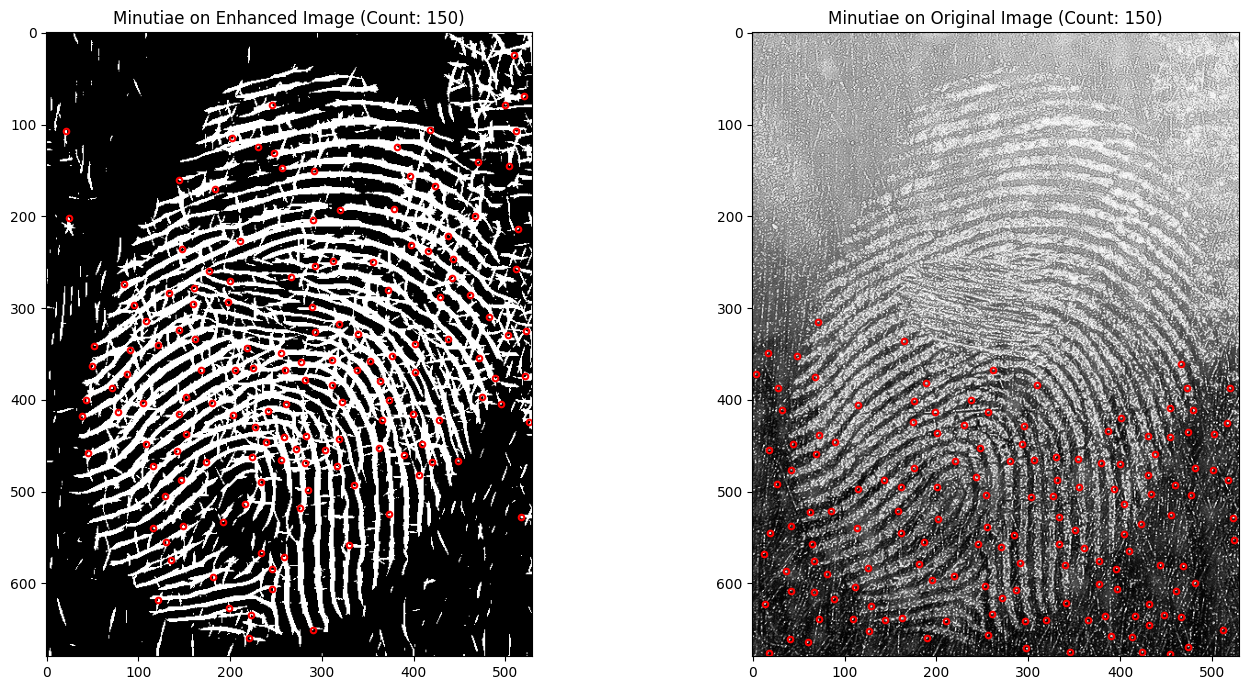

Features found in Enhanced: 150
Features found in Original: 150


In [ ]:
# Define parameters for the detector
max_corners = 150     
quality_level = 0.03  
min_distance = 18     

# Detect corners on Gabor-enhanced binary image (from Step 7)
corners_enhanced = cv2.goodFeaturesToTrack(enhanced_binary, max_corners, quality_level, min_distance)

# Detect corners on the original image
corners_original = cv2.goodFeaturesToTrack(eq_glass_img, max_corners, quality_level, min_distance)

# Display the detected corners on both images 
plt.figure(figsize=(15, 7))

# Plot 1: Enhanced Minutiae
plt.subplot(1, 2, 1)
plt.imshow(enhanced_binary, cmap='gray')
if corners_enhanced is not None:
    for i in corners_enhanced:
        x, y = i.ravel()
        plt.plot(x, y, 'ro', markersize=4, fillstyle='none', markeredgewidth=1.5) # Hollow red circle
plt.title(f"Minutiae on Enhanced Image (Count: {len(corners_enhanced)})")

# Plot 2: Original Minutiae
plt.subplot(1, 2, 2)
plt.imshow(eq_glass_img, cmap='gray')
if corners_original is not None:
    for i in corners_original:
        x, y = i.ravel()
        plt.plot(x, y, 'ro', markersize=4, fillstyle='none', markeredgewidth=1.5)
plt.title(f"Minutiae on Original Image (Count: {len(corners_original)})")

plt.tight_layout()
plt.show()

print(f"Features found in Enhanced: {len(corners_enhanced)}")
print(f"Features found in Original: {len(corners_original)}")

#### Step 9: Tune the hyperparameters to find the best enhanced image and best minutia detection for each images, load and show these images below.

--- Tuning glass.png ---
Set 1: Found 100 minutiae
Set 2: Found 100 minutiae
--- Tuning reddit.png ---
Set 1: Found 100 minutiae
Set 2: Found 100 minutiae


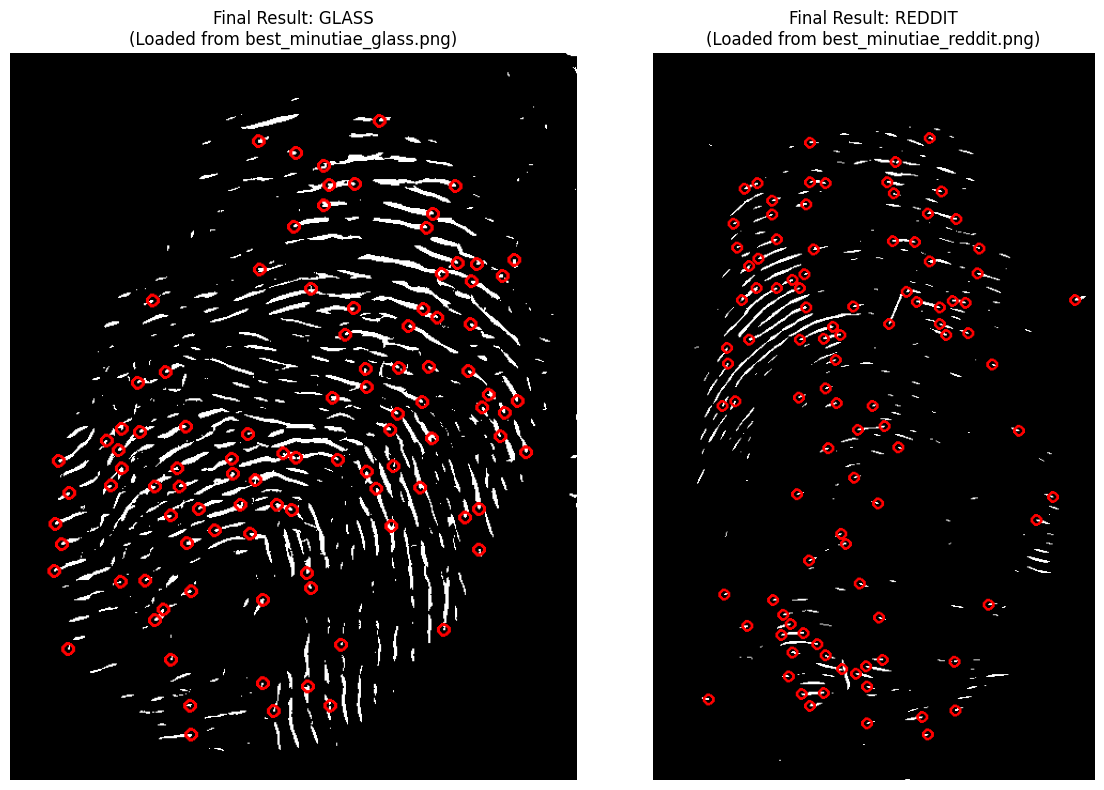

In [ ]:
# 1. Define the pipeline 
def process_pipeline(image, blur_sigma, g_sigma, g_freq, t_ratio, d=16, k=12):
    """Executes Steps 4-8 with dynamic kernel sizing and tunable blur."""
    
    # [Step 4 & 5: Gradient Orientation with Dynamic Blur]
    # We calculate the kernel size based on blur_sigma (standard is 6*sigma)
    b_ksize = int(6 * blur_sigma) | 1 
    blurred = cv2.GaussianBlur(image, (b_ksize, b_ksize), blur_sigma)
    
    Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    orientation = np.arctan2(Gy, Gx)
    
    # Block average orientation
    avg_kernel = np.ones((d, d), dtype=np.float32) / (d * d)
    avg_orientation = cv2.filter2D(orientation.astype(np.float32), -1, avg_kernel)[::d, ::d]
    
    # [Step 6 & 7: Gabor Enhancement with Dynamic Gabor Kernel]
    # We calculate the Gabor kernel size based on g_sigma
    g_ksize = int(5 * g_sigma) | 1
    
    bin_edges = np.linspace(-np.pi, np.pi, k + 1)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    filters = []
    for theta in bin_centres:
        kern = cv2.getGaborKernel((g_ksize, g_ksize), g_sigma, theta, 10.0, g_freq, 0, ktype=cv2.CV_64F)
        kern /= 1.0 * kern.sum()
        filters.append(kern)
    
    responses = [cv2.filter2D(image, cv2.CV_64F, f) for f in filters]
    combined = np.max(np.array(responses), axis=0)
    
    # Enhancement & Thresholding
    enhanced_binary = (combined > t_ratio * combined.max()).astype(np.uint8) * 255
    return enhanced_binary

# 2. Update the configurations for both images with two sets of parameters each (total 4 sets)
image_configs = {
    'glass': {
        'img': gray_glass_img[70:750, 550:1080],
        'params': [
            {'blur_sigma': 1.2, 'g_sigma': 3.0, 'g_freq': 0.6, 't_ratio': 0.5}, # Set 1
            {'blur_sigma': 1.5, 'g_sigma': 3.5, 'g_freq': 0.6, 't_ratio': 0.55} # Set 2
        ]
    },
    'reddit': {
        'img': gray_reddit_img[1560:2350, 1220:1700],
        'params': [
            {'blur_sigma': 1.2, 'g_sigma': 3.0, 'g_freq': 0.6, 't_ratio': 0.6}, # set1 
            {'blur_sigma': 1.5, 'g_sigma': 3.5, 'g_freq': 0.7, 't_ratio': 0.65} # set 2
        ]
    }
}

# 3. Tuning Loop
# Create a dictionary to store the best results for each image
best_results = {}

for name, config in image_configs.items():
    print(f"--- Tuning {name}.png ---")
    eq_img = cv2.equalizeHist(config['img'])
    
    best_count = 0
    best_img_to_save = None

    for i, p in enumerate(config['params']):
        binary_output = process_pipeline(
            eq_img, 
            p['blur_sigma'], 
            p['g_sigma'], 
            p['g_freq'], 
            p['t_ratio']
        )
        
        corners = cv2.goodFeaturesToTrack(binary_output, maxCorners=100, qualityLevel=0.53, minDistance=12)
        count = len(corners) if corners is not None else 0
        print(f"Set {i+1}: Found {count} minutiae")

        display_img = cv2.cvtColor(binary_output, cv2.COLOR_GRAY2BGR)
        if corners is not None:
            for corner in corners:
                x, y = corner.ravel().astype(int)
                cv2.circle(display_img, (x, y), 5, (0, 0, 255), 2)
        
        if count >= best_count:
            best_count = count
            best_img_to_save = display_img

    # Save results
    save_path = f"best_minutiae_{name}.png"
    cv2.imwrite(save_path, best_img_to_save)
    best_results[name] = save_path

# 4. Final Display
plt.figure(figsize=(12, 8))
for i, (name, path) in enumerate(best_results.items()):
    final_img = cv2.imread(path)
    final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 2, i+1)
    plt.imshow(final_img_rgb)
    plt.title(f"Final Result: {name.upper()}\n(Loaded from {path})")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Step 10: Discussion

The fingerprint enhancement pipeline follows a logical flow to transform noisy raw images into a clear set of minutiae. In the initial preprocessing stages, histogram equalization was essential because latent fingerprints on surfaces like glass or metal often have very low contrast. This step spread out pixel intensities, making the ridges visible for the computer to process. During the orientation mapping stage, we calculated gradients and used vector averaging to create a "flow map" of the fingerprint. This step is critical because it tells the computer exactly which direction the ridges are pointing in every specific part of the image, allowing the Gabor filter to work effectively.

The Gabor filtering and binarization steps are arguably the most important parts of the project. The Gabor filter acts like a selective brush that only enhances lines matching the local orientation of the fingerprint. This process fills in small gaps in the ridges while ignoring random background noise. Finally, the Harris Corner detector allowed us to extract the actual minutiae, such as ridge endings and bifurcations. Tuning was necessary at this stage because a "one-size-fits-all" approach failed to handle the different noise levels and lighting conditions of the two separate images.

Regarding parameters, we found that kernel size, sigma, and Gabor frequency had the most significant impact on quality. For Gaussian blurring, we used a sigma between 1.5 and 2.2. A smaller sigma keeps detail but leaves noise, while a larger sigma joins broken ridges but risks smudging them together. We used dynamic kernel sizes based on the sigma to ensure the blur always covered the mathematical spread of the distribution. The Gabor frequency was kept between 0.5 and 0.6 to represent the natural thickness of the ridges. If the frequency is too high, the ridges become thin and "shredded," but if it is too low, they merge into thick blobs.

In Step 9, we specifically used the maxCorners parameter to limit the number of minutiae to 100. During the tuning process, we observed that even when other parameters were adjusted, the detector often found an excessive amount of points due to the high sensitivity of the images. By setting a hard limit of 100, we were able to force the algorithm to focus only on the strongest, most reliable keypoints. This explains why the output count for all settings stayed at exactly 100; it ensured that the final results were not overwhelmed by noise and that only the highest-quality features were saved for the final display.

The same parameters did not work for both images due to their different environments. The glass image was relatively clean but had many broken ridge segments. It required more blurring and a lower frequency to help join those segments into solid lines. On the other hand, the Reddit image had a very bright, saturated glare on one side. This required a much higher threshold ratio to "starve" the background noise. Without this adjustment, the detector would mistake the white glare for a giant fingerprint ridge, leading to false minutiae detection.

Despite the success of this pipeline, there are several limitations. First, we assumed a global frequency, meaning we treated ridge thickness as the same across the whole finger. In reality, ridges are closer together near the loops and further apart at the edges. Second, the system is quite sensitive to noise; if the background has a pattern similar to a fingerprint, the Gabor filter might accidentally enhance the noise instead. Finally, the current process relies on manual tuning. A professional system would need automated algorithms to calculate local frequency and image quality without human intervention.